Plot the loss of the optimization process

In [88]:
import sys
sys.path.insert(1, 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts')

import matplotlib.pyplot as plt
import pickle

from utils import *

In [89]:
scripts_path = 'E:/OneDrive - UC San Diego/UCSD/Lab/Catheter/diff_catheter/scripts/test_diff_render_catheter_v2/gt_dataset/figs'
result_folder1 = "results_11232332/iter_0" # "results_01211907/iter_0", "results_11232332/iter_0"
filename = "data.pkl"
full_path = scripts_path + '/' + result_folder1 + '/' + filename

In [90]:
with open(full_path, "rb") as f:
    data = pickle.load(f)

if isinstance(data, dict):
    print("Keys in the .pkl file:", list(data.keys()))

Keys in the .pkl file: ['proj_end_effector_loss_history', 'd3d_end_effector_loss_history', 'd3d_mid_control_point_loss_history', 'loss_history', 'loss_contour_history', 'loss_tip_distance_history', 'loss_motion_model_history', 'para_init', 'p_start', 'gt_path', 'learning_rate']


In [91]:
def plot_loss(proj_end_effector_loss_history, title, ylabel):
    # Given array of values proj_end_effector_loss_history, create plot of loss vs. iterations
    iterations_x_axis_proj = list(range(len(proj_end_effector_loss_history)))
    
    plt.figure(dpi=300)
    plt.title(title)
    plt.plot(iterations_x_axis_proj, proj_end_effector_loss_history)
    
    plt.xlabel('Iterations')
    plt.ylabel(ylabel)
    
    plt.xlim([0, len(proj_end_effector_loss_history)])
    plt.ylim(bottom=0)  
    
    plt.grid(True)
    plt.show()


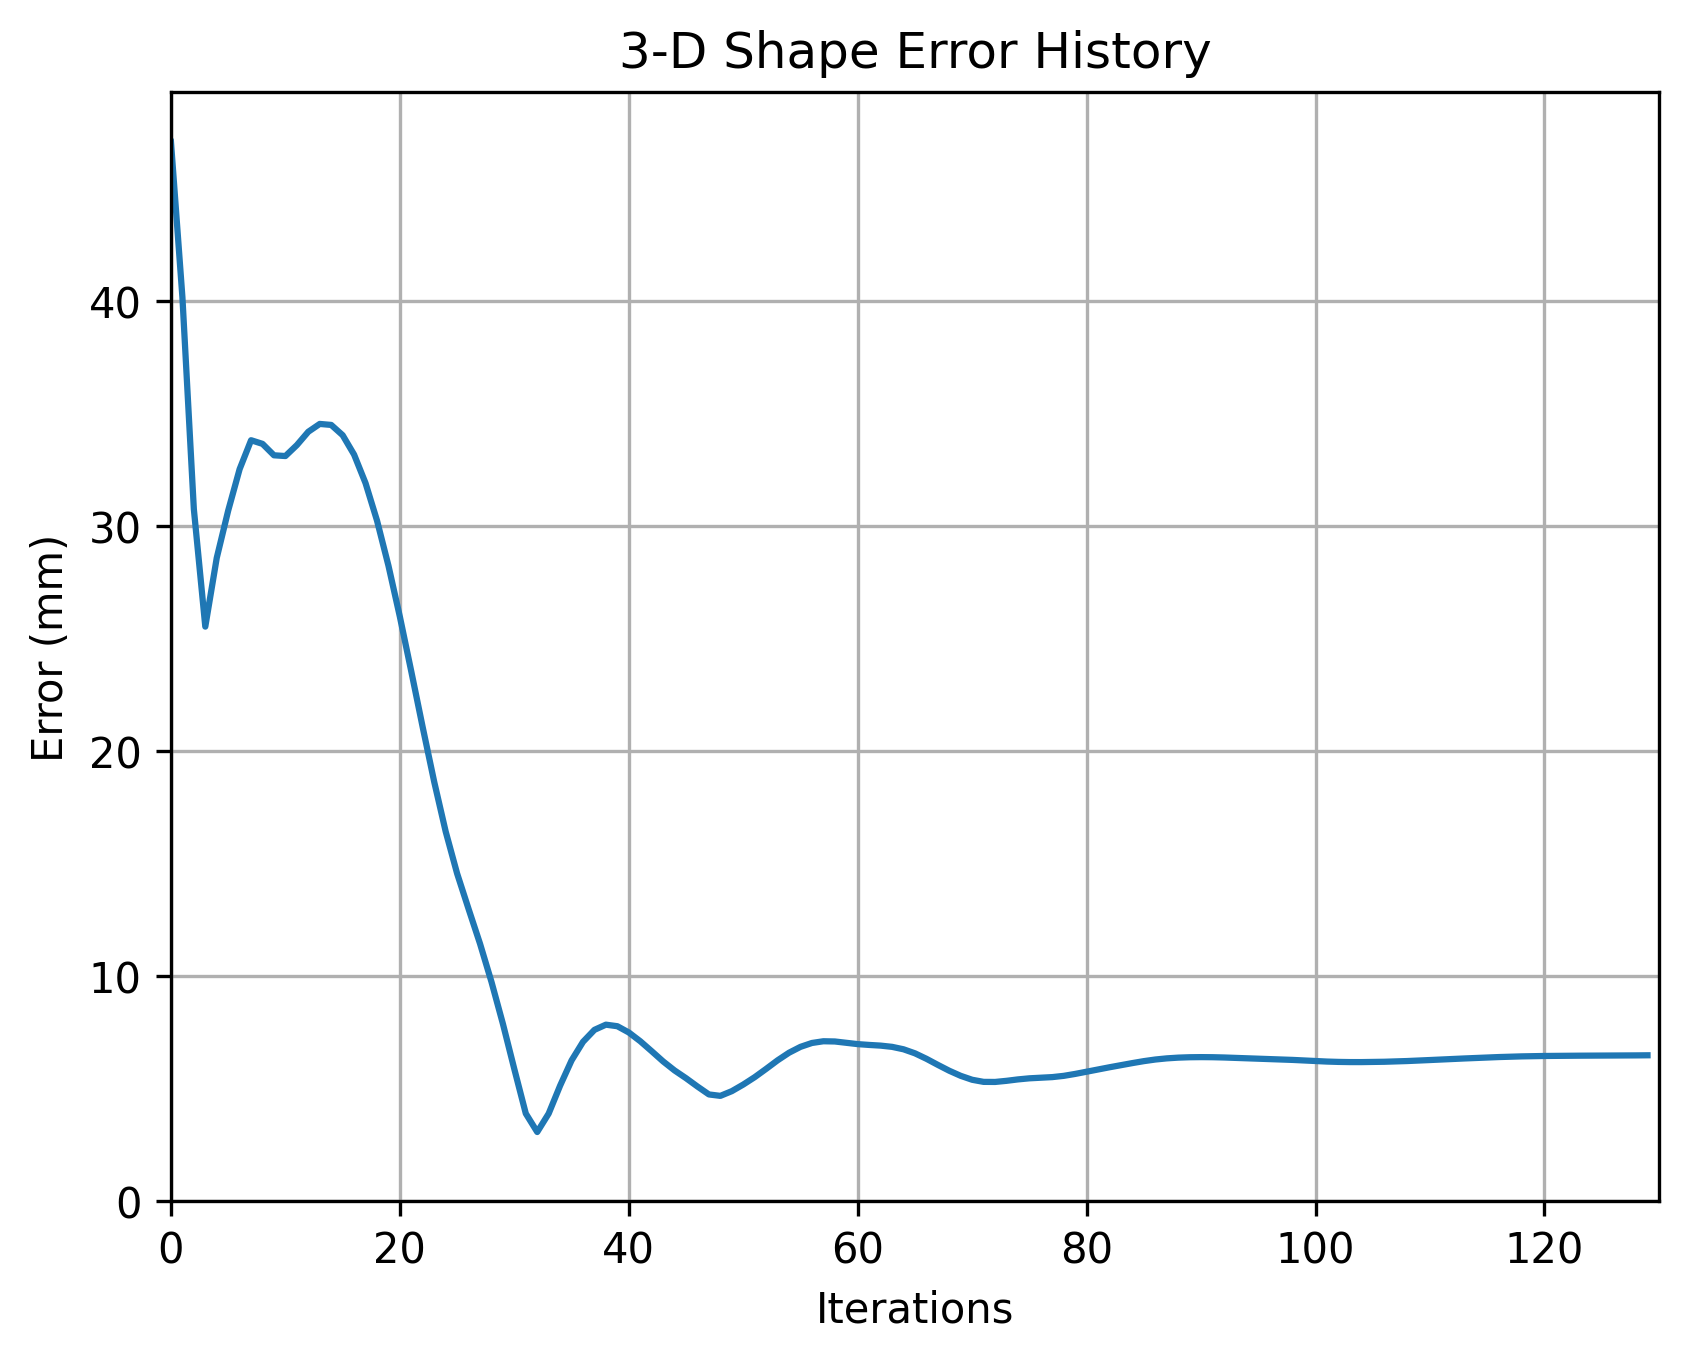

In [92]:
end_effector_error = data['d3d_end_effector_loss_history']
mid_error = data['d3d_mid_control_point_loss_history']
end_effector_error = [i*1000 for i in end_effector_error]
mid_error = [i*1000 for i in mid_error]

error_list = [(a + b) / 2 for a, b in zip(end_effector_error, mid_error)]

title = '3-D Shape Error History'
ylabel = 'Error (mm)'

plot_loss(error_list, title, ylabel)

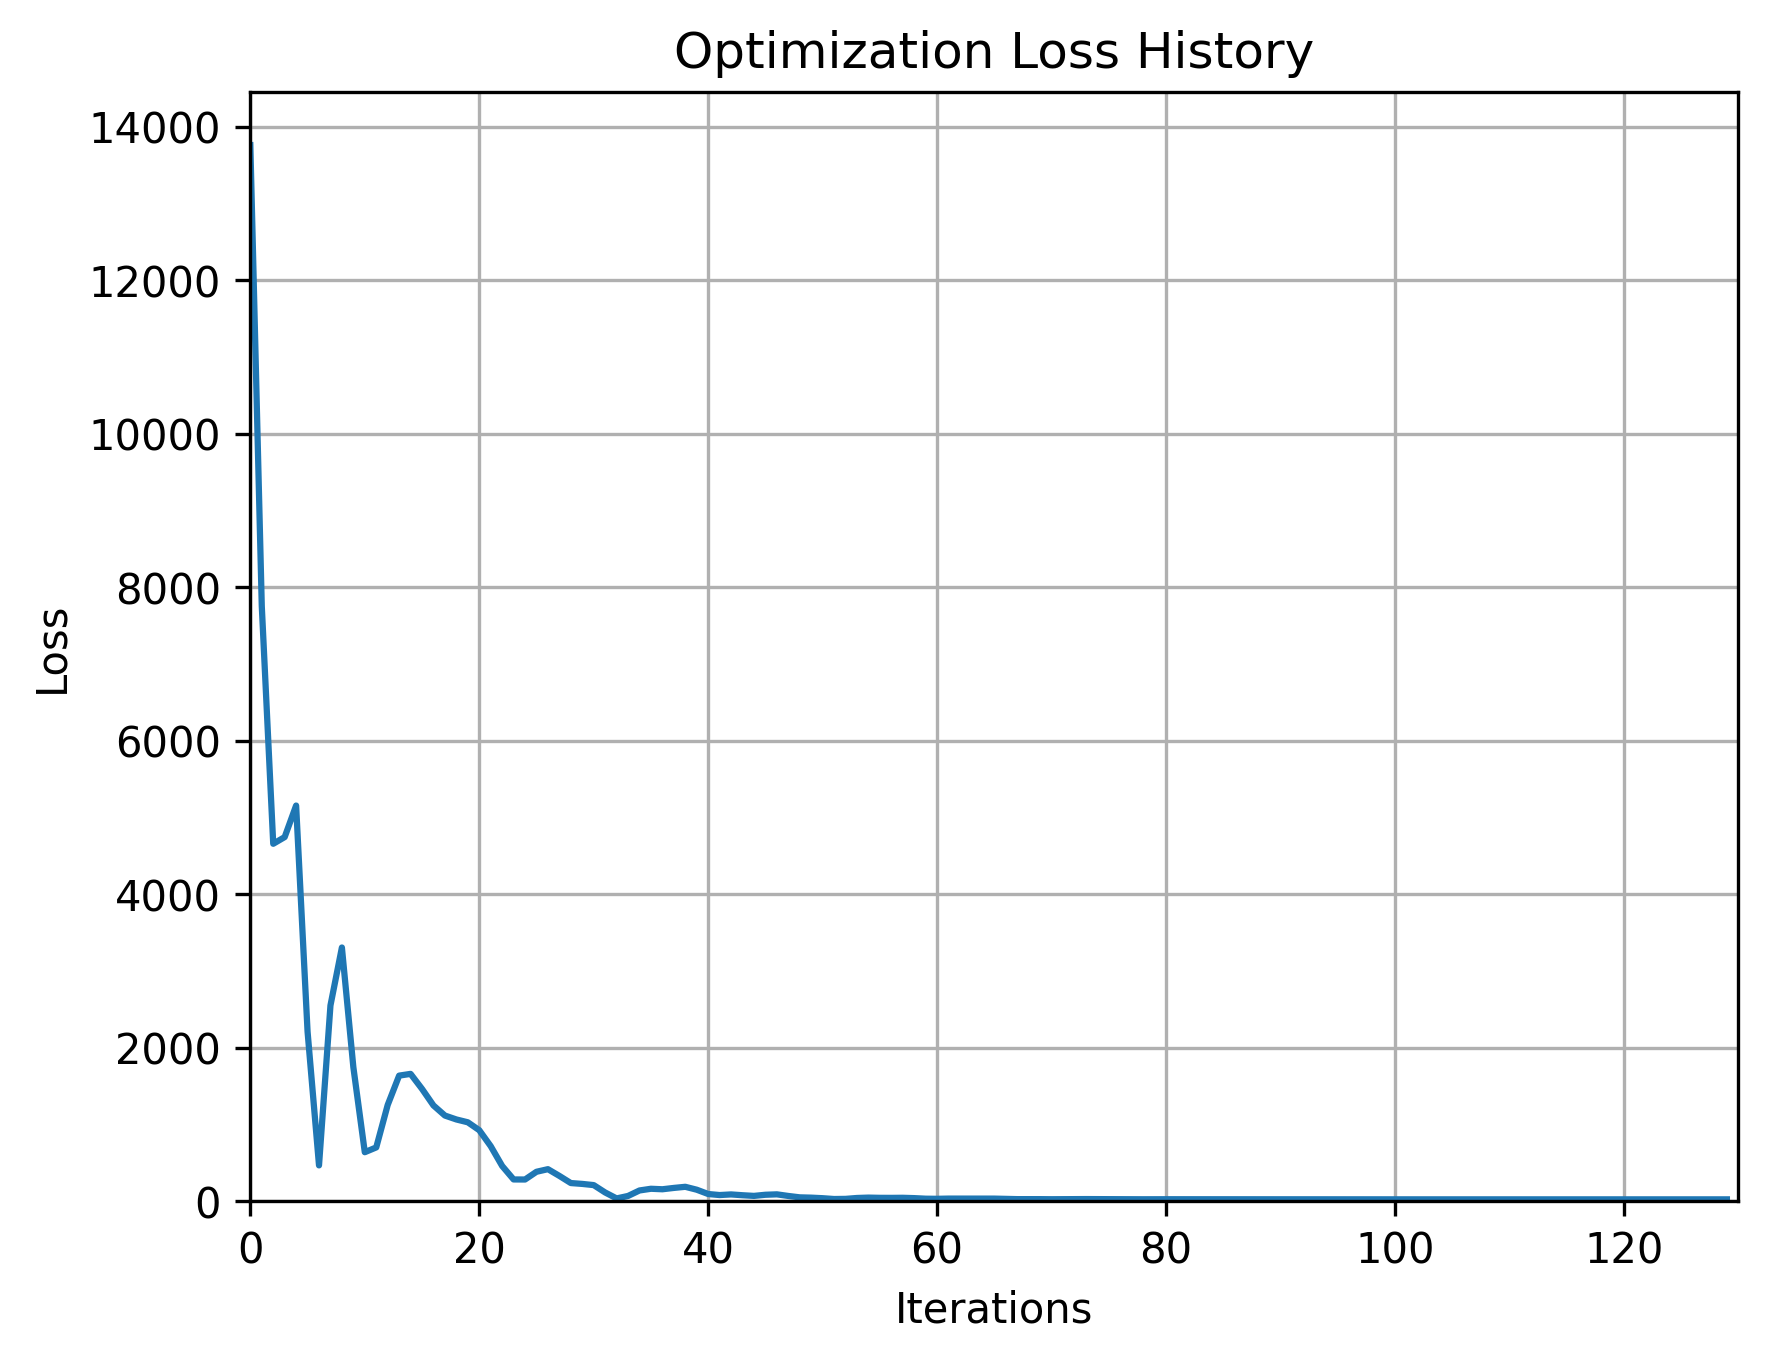

In [93]:
loss = data['loss_history']

title = 'Optimization Loss History'
ylabel = 'Loss'

plot_loss(loss, title, ylabel)

In [94]:
def plot_loss_ax(proj_end_effector_loss_history, title, ylabel, ax):
    """
    Plot loss vs. iterations on a given subplot axis.

    Parameters:
    proj_end_effector_loss_history: list
        Loss values over iterations.
    title: str
        Title of the plot.
    ylabel: str
        Label for the Y-axis.
    ax: matplotlib.axes._subplots.AxesSubplot
        The subplot axis to draw the plot on.
    """
    iterations_x_axis_proj = list(range(len(proj_end_effector_loss_history)))
    
    ax.set_title(title)
    ax.plot(iterations_x_axis_proj, proj_end_effector_loss_history)
    
    ax.set_xlabel('Iterations')
    ax.set_ylabel(ylabel)
    
    ax.set_xlim([0, len(proj_end_effector_loss_history)])
    ax.set_ylim(bottom=0)  
    
    ax.grid(True)

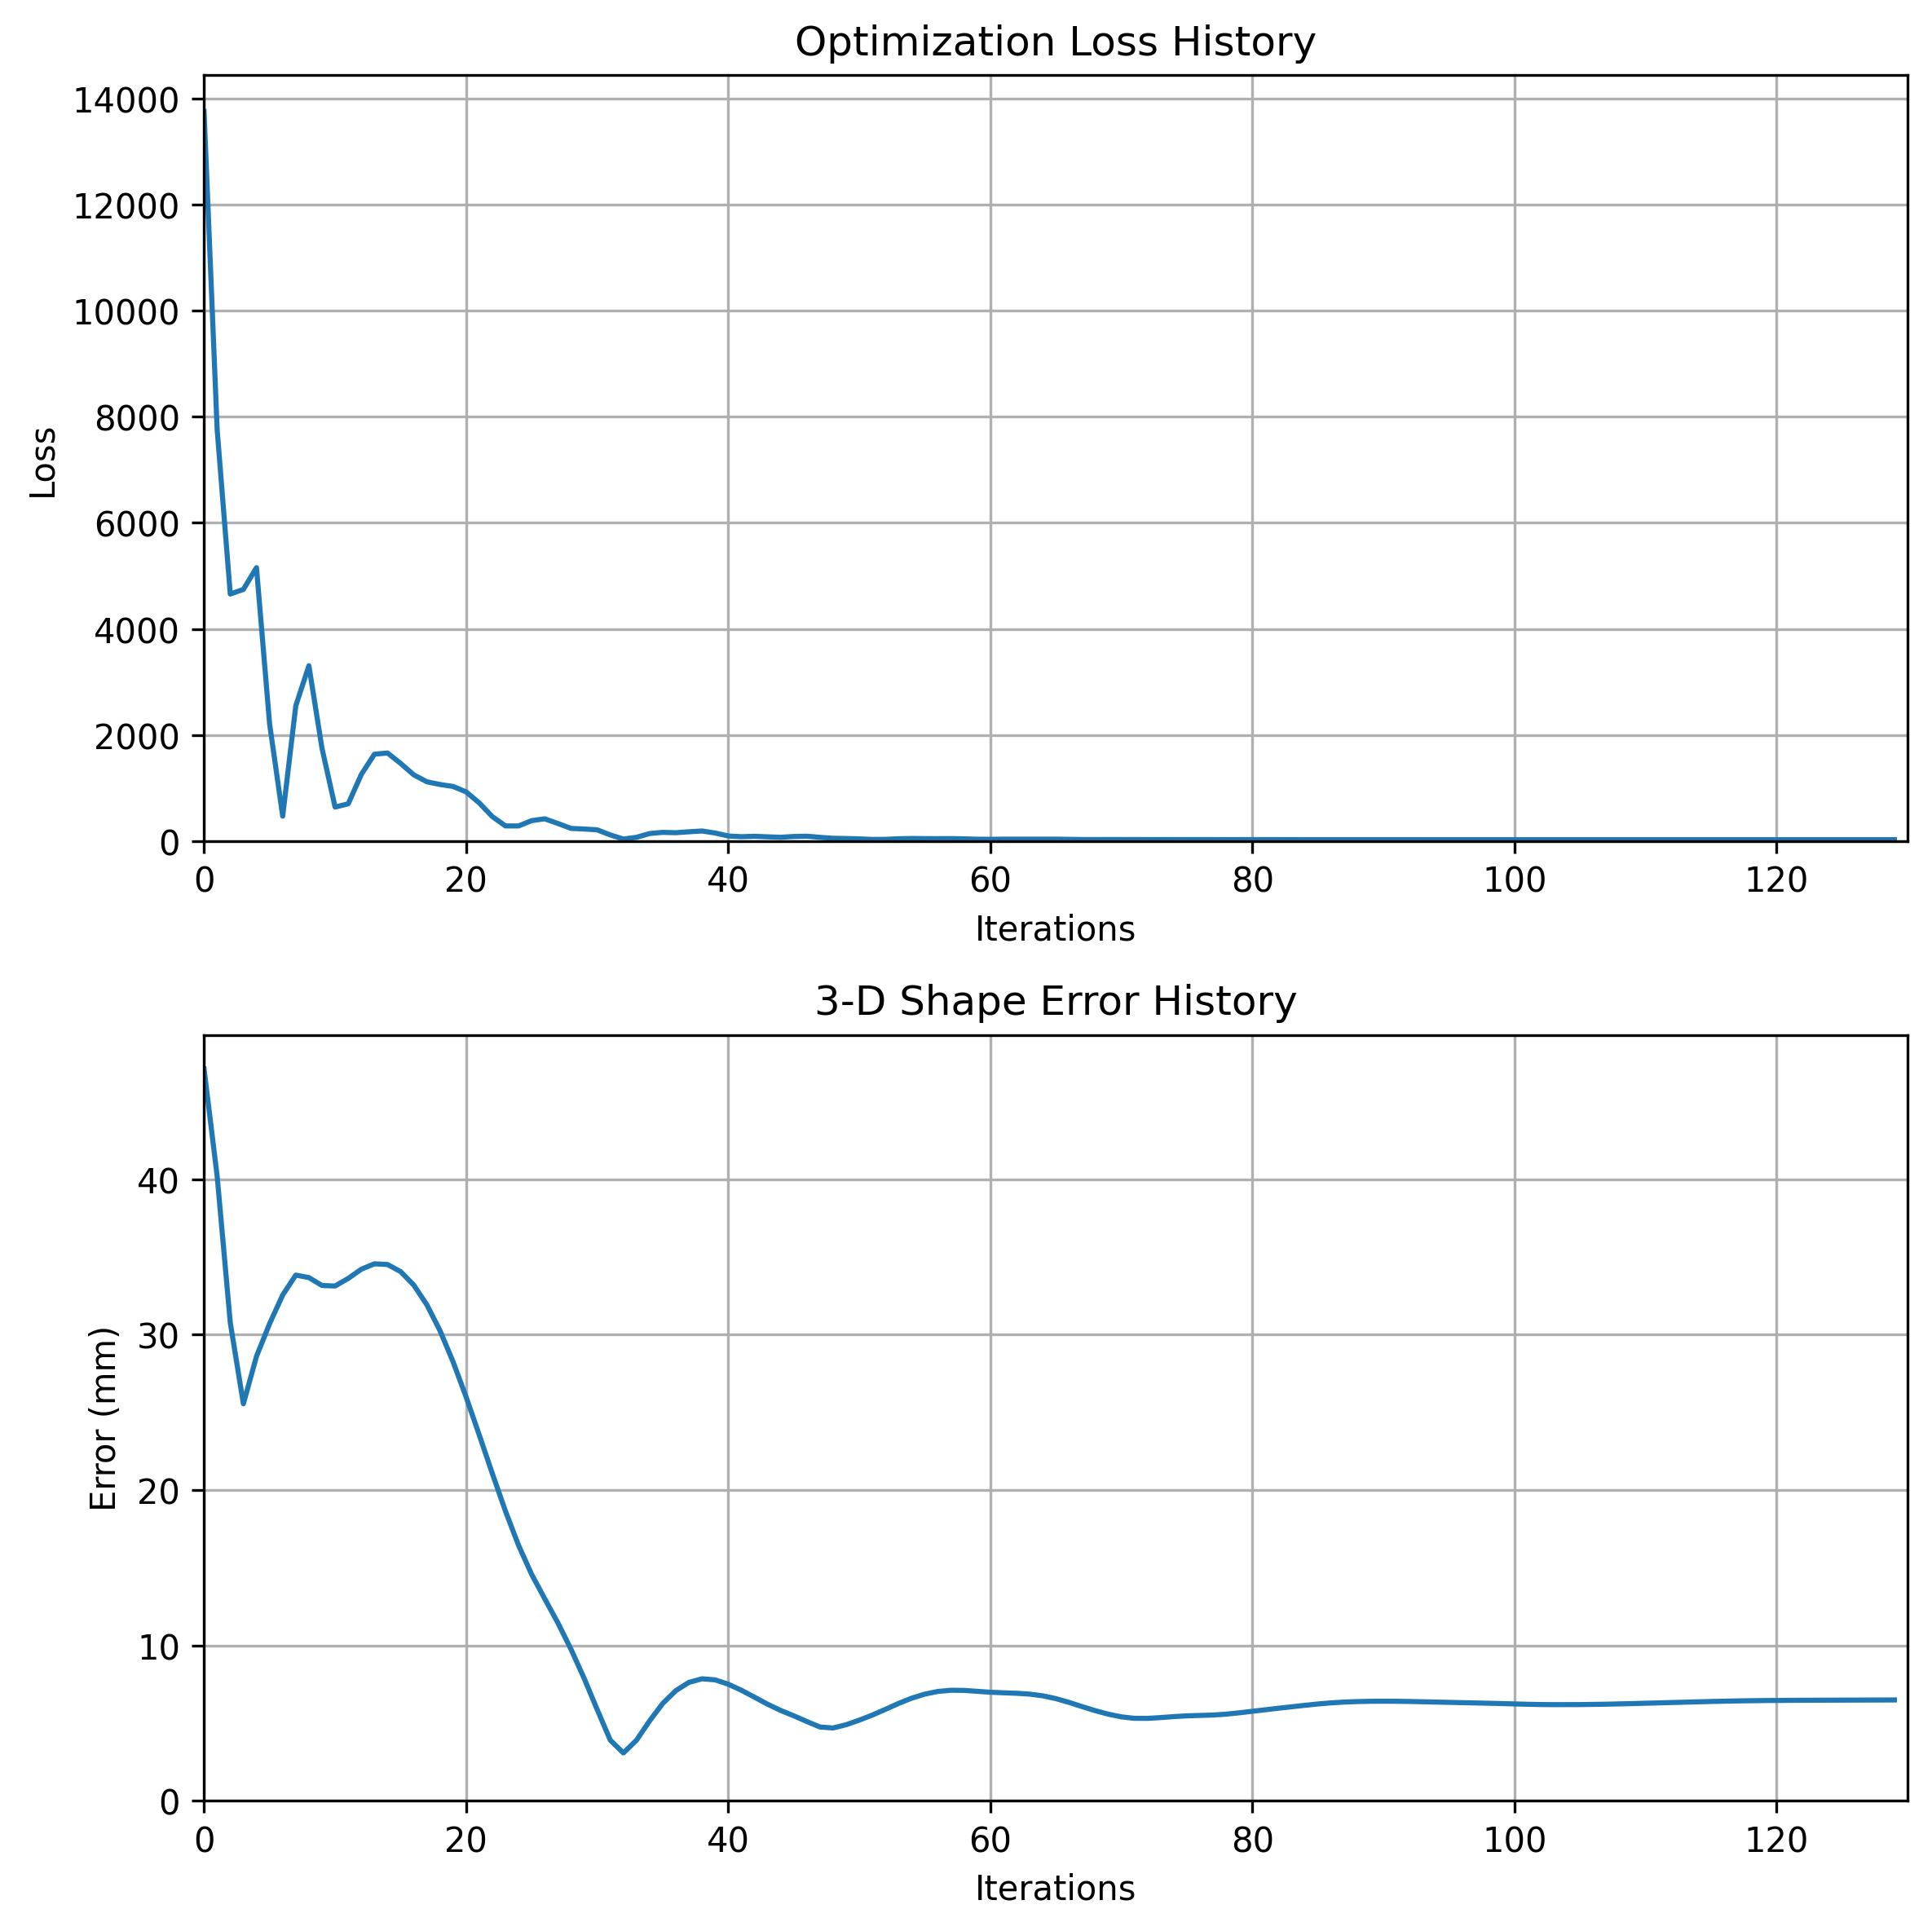

In [95]:
# 创建 2x1 的子图，并设置单个图像宽而矮
fig, axes = plt.subplots(2, 1, figsize=(8, 8), dpi=300)  # (宽度 10，高度 3)

# 绘制两幅图
plot_loss_ax(loss, 'Optimization Loss History', 'Loss', axes[0])
plot_loss_ax(error_list, '3-D Shape Error History', 'Error (mm)', axes[1])

# 调整子图间距，避免重叠
plt.tight_layout()
plt.show()

In [97]:
# import matplotlib.pyplot as plt

# def plot_loss_2(loss_list, labels, colors, title, ylabel):
#     """
#     Plot multiple loss curves with custom colors and labels.

#     Parameters:
#     loss_list: list of lists
#         Each inner list represents a loss history over iterations.
#     labels: list of str
#         Names of each curve for the legend.
#     colors: list of str
#         Colors for each curve.
#     title: str
#         Title of the plot.
#     ylabel: str
#         Label for the Y-axis.
#     """
#     plt.figure(dpi=300)
#     plt.title(title)

#     # Check if lists have the same length
#     if not (len(loss_list) == len(labels) == len(colors)):
#         raise ValueError("loss_list, labels, and colors must have the same length.")

#     # Plot each loss curve
#     for loss, label, color in zip(loss_list, labels, colors):
#         iterations_x_axis = list(range(len(loss)))
#         plt.plot(iterations_x_axis, loss, label=label, color=color)

#     plt.xlabel('Iterations')
#     plt.ylabel(ylabel)

#     # Set x-axis limit based on the longest loss sequence
#     max_length = max(len(loss) for loss in loss_list)
#     plt.xlim([0, max_length])

#     plt.ylim(bottom=0)  # Ensure non-negative loss values
#     plt.grid(True)

#     # Add legend
#     plt.legend()

#     plt.show()


In [98]:
# loss_history = data['loss_history']
# loss_contour_history = data['loss_contour_history']
# loss_tip_distance_history = data['loss_tip_distance_history']
# loss_motion_model_history = data['loss_motion_model_history']

# loss_tip_distance_history = [i/10 for i in loss_tip_distance_history]
# loss_motion_model_history = [i/100 for i in loss_motion_model_history]
# loss_history = error_list = [a + b + c for a, b, c in zip(loss_contour_history, loss_tip_distance_history, loss_motion_model_history)]


# loss_list = [
#     loss_history,
#     loss_tip_distance_history,
#     loss_contour_history,
#     loss_motion_model_history
# ]

# labels = ["Total Loss", "Tip Loss", "Contour Loss", "Motion Model Loss"]

# colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442"]

# title = 'Loss History'

# plot_loss_2(loss_list, labels, colors, title, ylabel="Loss (m)")

In [99]:
# loss_tip_distance_history = [i/10 for i in loss_tip_distance_history]

# loss_list = [
#     loss_tip_distance_history,
#     loss_contour_history
# ]

# labels = ["Tip Loss", "Contour Loss"]

# colors = ["#56B4E9", "#009E73"]

# title = 'Loss History'

# plot_loss_2(loss_list, labels, colors, title, ylabel="Loss (m)")